### CONDITIONAL GRAPH

In [2]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

In [4]:
class AgentState(TypedDict):
    number1: int
    number2: int
    operation: str
    result: int

In [5]:
def adder(state: AgentState) -> AgentState:
    """This node adds two numbers"""
    state['result'] = state['number1'] + state['number2']
    return state

In [6]:
def subtractor(state: AgentState) -> AgentState:
    """This node substracts two numbers"""
    state['result'] = state['number1'] - state['number2'] if state['number1'] > state['number2'] else state['number2'] - state['number1']
    return state

In [7]:
def decider(state: AgentState) -> AgentState:
    """This node decides the flow based on operation"""

    if state['operation'] == '+':
        return 'addition_operation'
    
    elif state['operation'] == '-':
        return 'subtraction_operation'
    
    # return state

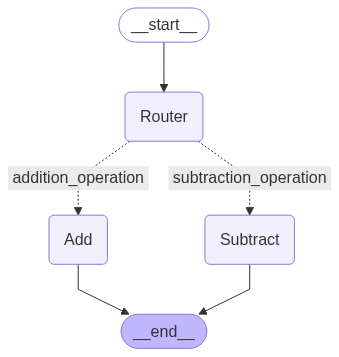

In [8]:
graph = StateGraph(AgentState)
graph.add_node('Router',lambda state: state)  ### pass through function, input state = output state
graph.add_node('Add',adder)
graph.add_node('Subtract',subtractor)

graph.add_edge(START,'Router')

graph.add_conditional_edges(
    'Router',
    decider,
    {   # Edge: Node
        'addition_operation':'Add',
        'subtraction_operation':'Subtract'
    }
)

graph.add_edge('Add',END)
graph.add_edge('Subtract',END)

graph.compile()


In [9]:
app = graph.compile()

In [ ]:
answer = app.invoke({'number1':10, 'number2':5, 'operation':'+'})
print(answer)

answer2 = app.invoke({'number1':5, 'number2':10, 'operation':'-'})
print(answer2)

{'number1': 10, 'number2': 5, 'operation': '+', 'result': 15}
{'number1': 5, 'number2': 10, 'operation': '-', 'result': 5}
{'number1': 10, 'number2': 5, 'operation': '-', 'result': 5}
{'number1': 10, 'number2': 0, 'operation': '-', 'result': 10}
{'number1': 0, 'number2': 3, 'operation': '+', 'result': 3}
